# PS-S06E05: XGBoost

This notebook tackles the [**Playground Series – Season 6, Episode 5: Predicting F1 Pit Stops**](https://www.kaggle.com/competitions/playground-series-s6e5), a competition focused on predicting the probabilty that a driver will pit on the next lap, based on with engineered features that capture tire degradation, race progression, and driver performance dynamics.

## Introduction

**XGBoost** is highly effective at capturing non-linear relationships between race-day variables—such as tire age, track degradation, and race progress—and the target. It handles missing values internally and includes regularization (L1/L2) to prevent overfitting.  
We utilize XGBoost's native categorical support (`enable_categorical=True`) to handle variables like `Driver`, `Compound`, and `Race` without the need for manual One-Hot Encoding.  
The notebook is one of a number of notebooks that explore various models to address this challenge.  The EDA for this dataset was performed in this notebook: [**PS-S06E05: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e05-eda).

In [1]:
import os
import gc
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# Third-party
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import RFECV
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e05_feature_engineering import FeatureFactory
from ps_s06e05_model_visualizer import ModelVisualizer
from ps_s06e05_experiment_setup import ExperimentSetup

# Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'PitNextLap'

# Show GPU be utilized in training
USE_GPU = False

# Recursive Feature Elimination should be performed in the pipeline.
PERFORM_RFE = False

# Optuna tuning should be performed in the pipeline
PERFORM_OPTUNA_TUNING = False

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [3]:
training_df = helper.read_dataset('training')

TRAINING DATASET

   id Driver Compound                   Race  Year  PitStop  LapNumber  Stint  \
0   0   D109     HARD    Canadian Grand Prix  2022        0         50      2   
1   1   D086     HARD       Dutch Grand Prix  2025        1         27      2   
2   2    ZON     HARD    Austrian Grand Prix  2022        0         59      3   
3   3    SPE   MEDIUM     Pre-Season Testing  2023        0          2      1   
4   4   D019     HARD  Azerbaijan Grand Prix  2022        1         26      3   

   TyreLife  Position  LapTime (s)  LapTime_Delta  Cumulative_Degradation  \
0    39.000         8       78.491         -7.564                  21.019   
1     7.000         4       75.095        -32.617                -223.207   
2    22.000        13       70.945         -7.540                -100.529   
3     2.000         7       94.361         -7.324                  -7.324   
4     6.000         2      107.878          8.965                 -14.139   

   RaceProgress  Position_Change

In [4]:
test_df = helper.read_dataset('test')

TEST DATASET

       id Driver Compound                      Race  Year  PitStop  LapNumber  \
0  439140   D119   MEDIUM        British Grand Prix  2023        0         21   
1  439141    VER   MEDIUM      Abu Dhabi Grand Prix  2023        0         24   
2  439142   D270   MEDIUM        British Grand Prix  2023        0         24   
3  439143   D112     SOFT      São Paulo Grand Prix  2024        0          6   
4  439144    AND     HARD  United States Grand Prix  2024        0         52   

   Stint  TyreLife  Position  LapTime (s)  LapTime_Delta  \
0      1    21.000         4       93.387          0.280   
1      1    24.000         1       90.867         -0.129   
2      1    24.000        11       92.871          0.041   
3      2     4.000        15       94.967        -19.741   
4      2    29.000        12       99.112          0.930   

   Cumulative_Degradation  RaceProgress  Position_Change  
0                  -4.984         0.404            0.000  
1                  -

## Feature Engineering

In [5]:
# Define which strategies to use for the XGBoost model here:
fe_strategies = [
    'encoding',
    'race_dynamics',
    'tire_physics',
]

In [6]:
print('Performing initial feature engineering.')

# Get the target before we start messing with features
y = training_df[TARGET]

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 15
New Feature Count: 23
   Driver  Compound  Race  Year  PitStop  LapNumber  Stint  TyreLife  \
0     134         0     7  2022        0         50      2    39.000   
1     111         0     9  2025        1         27      2     7.000   
2     886         0     2  2022        0         59      3    22.000   
3     864         2    19  2023        0          2      1     2.000   
4      44         0     3  2022        1         26      3     6.000   

   Position  LapTime (s)  LapTime_Delta  Cumulative_Degradation  RaceProgress  \
0         8       78.491         -7.564                  21.019         0.714   
1         4       75.095        -32.617                -223.207         0.346   
2        13       70.945         -7.540                -100.529         0.819   
3         7       94.361         -7.324                  -7.324         0.077   
4         2      107.878          8.965                 -14.139         0.361 

## Optional Recursive Feature Elimination and Optuna Training

If the `PERFORM_RFE` variable in cell 3 is set to True, Recursive Feature Elimination (RFE) is performed.  This works by training the model, identifying the weakest feature, deleting it, and then re-training. It repeats this process until it finds the exact subset of features that gives the highest Cross-Validation score.  This step is performed on a temporary feature engineered dataset to determine the optimal set of features, which are used to filter the in-fold feature engineered dataset.  If the variable is set to False, all features are used in training.

If the `PERFORM_OPTUNA_TUNING` variable in cell 3 is set to True, an Optuna trial is performed to determine the best set of hyperscaling parameters.  If training isn't requested, a set of hyperparameters derived from an earlier run is used instead.

In [7]:
n_jobs = 1 if USE_GPU else -1

X_rfe = X.copy()

# Convert all object and category columns to integer codes
cat_cols_rfe = X_rfe.select_dtypes(include=['category', 'object']).columns
for col in cat_cols_rfe:
    X_rfe[col] = X_rfe[col].astype('category').cat.codes
    
if PERFORM_RFE:    
    # Suppress the specific XGBoost warning to clean up the output
    warnings.filterwarnings('ignore', category=UserWarning, module='xgboost.core')
    
    # Use a conservative estimator for selection
    # High depth, moderate learning rate to find signal quickly
    clf = xgb.XGBClassifier(
        n_estimators=200, 
        learning_rate=0.1, 
        max_depth=4, 
        tree_method='hist',
        device='cpu',
        objective='binary:logistic',
        random_state=seed,
        n_jobs=n_jobs
    )

    # Use 'neg_root_mean_squared_error' for regression
    rfecv = RFECV(
        estimator=clf,
        step=1,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=seed),
        scoring='auc', 
        min_features_to_select=15,
        n_jobs=n_jobs,
        verbose=1
    )

    print('Running Recursive Feature Elimination (this will take a few minutes)...')
    rfecv.fit(X_rfe, y)
    
    # Results
    print(f'Optimal number of features: {rfecv.n_features_}')
    
    # Plotting results
    plt.figure(figsize=(10, 6))
    plt.xlabel('Number of features selected')
    plt.ylabel('Cross-validation score (ROC AUC)')
    plt.plot(
        range(rfecv.min_features_to_select, len(rfecv.cv_results_['mean_test_score']) + rfecv.min_features_to_select),
        rfecv.cv_results_['mean_test_score']
    )
    plt.title('RFE Performance for Irrigation Need')
    plt.show()
    
    # Save the selected features for the next step
    optimal_cols = X_rfe.columns[rfecv.support_]
else:
    print('Using all columns as optimal features.')
    optimal_cols = X_rfe.columns
        
print('\nOptimal Features:')
print(optimal_cols.tolist())

Using all columns as optimal features.

Optimal Features:
['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'TotalLaps', 'LapsRemaining', 'PositionVolatility', 'RemainingRace', 'StintProgress', 'PositionChange', 'DegradationRate', 'Log_Degradation', 'LogWear']


In [8]:
def objective(trial):
    
    # Suggest Parameters
    param = {
        # Core Booster Params
        'n_estimators': 10000,
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 100.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.8),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 10.0),
    
        # Regularization
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 100.0, log=True),  # L1
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 100.0, log=True), # L2
        'gamma': trial.suggest_float('gamma', 0.1, 10.0),
        
        # Tree Structure
        'grow_policy': trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide']),
        
        # Boilerplate
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'enable_categorical': True,
        'tree_method': 'gpu_hist' if USE_GPU else 'hist',
        'early_stopping_rounds': 200,
        'random_state': seed,
        'n_jobs': n_jobs
    }

    # Ensure optimal_cols is a standard list for filtering
    cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols
    
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    
    oof_probs = np.zeros(len(y))

    # Standard CV Loop
    for fold, (train_idx, val_idx) in enumerate(kf.split(training_df, y)):
        
        # Create Folds
        X_train_fold = training_df.iloc[train_idx]
        y_train_fold = y.iloc[train_idx]
        
        X_val_fold = training_df.iloc[val_idx]
        y_val_fold = y.iloc[val_idx]
        
        # Feature Engineering (Per fold to prevent leakage)
        fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
        
        X_train_trans = fe_fold.fit_transform(X_train_fold)
        X_val_trans = fe_fold.transform(X_val_fold)

        # Restrict to optimal column set
        if cols_to_keep is not None:
            final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
            if not final_cols:
                raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
            X_train_trans = X_train_trans[final_cols]
            X_val_trans   = X_val_trans[final_cols]
        
        # Guard: ensure no object dtypes slip through (XGB native-cat wants category)
        obj_cols = X_train_trans.select_dtypes(include=['object']).columns.tolist()
        for col in obj_cols:
            X_train_trans[col] = X_train_trans[col].astype('category')
            X_val_trans[col]   = X_val_trans[col].astype('category')

        # Create model (Classifier)
        model = xgb.XGBClassifier(**param)

        # Calculate weights to support Balanced Accuracy
        weights = compute_sample_weight('balanced', y_train_fold)
        
        # Train the model
        model.fit(
            X_train_trans, y_train_fold,
            sample_weight=weights,
            eval_set=[(X_val_trans, y_val_fold)],
            verbose=False
        )
        
        # Predict
        probs = model.predict_proba(X_val_trans)[:, 1]
        oof_probs[val_idx] = probs

    return roc_auc_score(y, oof_probs)


In [9]:
if PERFORM_OPTUNA_TUNING:
    print('Starting XGBoost Optuna Optimization...')
    
    # Use MedianPruner for efficiency
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=10
    )
    
    study_xgb = optuna.create_study(
        direction='maximize',
        study_name='xgb_predict_f1_pit_stops_optuna', 
        pruner=pruner
    )
    
    study_xgb.optimize(
        objective,
        n_trials=50,
        show_progress_bar=True,
        timeout=18000,  # 5 hours
    )
    
    print('\nBest Trial:')
    print(f'   ROC AUC: {study_xgb.best_value:.5f}')
    print('   Params: ', study_xgb.best_params)
    
    xgb_best_params = study_xgb.best_params
else:
    xgb_best_params = {
        'learning_rate': 0.006798956246856194,
        'max_depth': 10,
        'min_child_weight': 29.510571817421777,
        'subsample': 0.742626778351735,
        'colsample_bytree': 0.6992531826724849,
        'scale_pos_weight': 5.0569414139158,
        'reg_alpha': 2.1089799360843523e-05,
        'reg_lambda': 2.556783112419703e-05,
        'gamma': 3.521116982187733,
        'grow_policy': 'lossguide'
    }
    
    print('\nUsing earlier calculated params:')
    print('  Params: ', xgb_best_params)


[I 2026-05-11 12:42:30,448] A new study created in memory with name: xgb_predict_f1_pit_stops_optuna


Starting XGBoost Optuna Optimization...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-11 12:43:22,673] Trial 0 finished with value: 0.9483829870007201 and parameters: {'learning_rate': 0.03739981292911577, 'max_depth': 10, 'min_child_weight': 1.0100061442846082, 'subsample': 0.9995831744784751, 'colsample_bytree': 0.4224150645134524, 'scale_pos_weight': 3.129310215098283, 'reg_alpha': 4.3313001272806736e-08, 'reg_lambda': 0.008733071980742134, 'gamma': 6.655428030765895, 'grow_policy': 'lossguide'}. Best is trial 0 with value: 0.9483829870007201.
[I 2026-05-11 12:46:28,169] Trial 1 finished with value: 0.946431225436245 and parameters: {'learning_rate': 0.007583052417081402, 'max_depth': 5, 'min_child_weight': 21.344837832362025, 'subsample': 0.5078673962339316, 'colsample_bytree': 0.6360307288349538, 'scale_pos_weight': 8.15922141437904, 'reg_alpha': 0.012299622143747769, 'reg_lambda': 0.01422820224352427, 'gamma': 5.6498367010314885, 'grow_policy': 'depthwise'}. Best is trial 0 with value: 0.9483829870007201.
[I 2026-05-11 12:47:33,579] Trial 2 finished wit

## Model Training

In [10]:
xgb_tuned_params = {
    **xgb_best_params, # Unpack Optuna best params
    'n_estimators': 8000,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'n_jobs': n_jobs,
    'random_state': seed,
    'enable_categorical': True,      # Native categorical support
    'early_stopping_rounds': 100,
    'tree_method': 'gpu_hist' if USE_GPU else 'hist',
}

print('Final XGBoost CV Training with OOF / Test probabilities')
print('=======================================================')
print('Parameters used for training:')
print(xgb_tuned_params)

# Ensure optimal_cols is a standard list
cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols

# Initialize Standard K-Fold
n_folds = 5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

# Storage for plotting later
eval_results = []
models = []

# Arrays to store results
oof_probs = np.zeros(len(y))
test_probs = np.zeros(len(test_df))
oof_preds = np.zeros(len(y))

# Standard CV Loop
for fold, (train_idx, val_idx) in enumerate(kf.split(training_df, y)):
    print(f'Starting processing of fold {fold+1}')

    # Create Folds
    X_train_fold = training_df.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    
    X_val_fold = training_df.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]
    
    # Feature Engineering
    fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    
    X_train_trans = fe_fold.fit_transform(X_train_fold)
    X_val_trans = fe_fold.transform(X_val_fold)
    X_test_trans = fe_fold.transform(test_df)
    
    # Restrict to optimal column set
    if cols_to_keep is not None:
        final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
        if not final_cols:
            raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
        X_train_trans = X_train_trans[final_cols]
        X_val_trans   = X_val_trans[final_cols]
        X_test_trans  = X_test_trans[final_cols]

    # Guard: ensure no object dtypes slip through (XGB native-cat wants category)
    obj_cols = X_train_trans.select_dtypes(include=['object']).columns.tolist()
    for col in obj_cols:
        X_train_trans[col] = X_train_trans[col].astype('category')
        X_val_trans[col]   = X_val_trans[col].astype('category')
        X_test_trans[col]  = X_test_trans[col].astype('category')

    # Create model (Classifier)
    model = xgb.XGBClassifier(**xgb_tuned_params)

    weights = compute_sample_weight('balanced', y_train_fold)
    
    # Train Model
    model.fit(
        X_train_trans, y_train_fold,
        # eval_set order: [train, validation] so we can track both
        eval_set=[(X_train_trans, y_train_fold), (X_val_trans, y_val_fold)],
        sample_weight=weights,
        verbose=500
    )
    
    # Store history
    eval_results.append(model.evals_result())
    models.append(model)
    
    # Predict OOF probabilities
    # Predict OOF probabilities for the positive class (PitNextLap = 1)
    probs = model.predict_proba(X_val_trans)[:, 1]
    preds = (probs >= 0.5).astype(int)
    
    oof_probs[val_idx] = probs
    oof_preds[val_idx] = preds
    
    # Score this fold
    fold_score = roc_auc_score(y_val_fold, probs)
    print(f'Fold {fold+1} ROC AUC Score: {fold_score:.6f} (best_iteration={model.best_iteration})')
    
    # Accumulate Test Probs
    test_probs += model.predict_proba(X_test_trans)[:, 1] / n_folds

# Final Metric Calculation
overall_score = roc_auc_score(y, oof_probs)
print(f"Overall OOF ROC AUC Score: {overall_score:.5f}")

Final XGBoost CV Training with OOF / Test probabilities
Parameters used for training:
{'learning_rate': 0.006798956246856194, 'max_depth': 10, 'min_child_weight': 29.510571817421777, 'subsample': 0.742626778351735, 'colsample_bytree': 0.6992531826724849, 'scale_pos_weight': 5.0569414139158, 'reg_alpha': 2.1089799360843523e-05, 'reg_lambda': 2.556783112419703e-05, 'gamma': 3.521116982187733, 'grow_policy': 'lossguide', 'n_estimators': 8000, 'objective': 'binary:logistic', 'eval_metric': 'auc', 'n_jobs': 1, 'random_state': 10301, 'enable_categorical': True, 'early_stopping_rounds': 100, 'tree_method': 'gpu_hist'}
Starting processing of fold 1
[0]	validation_0-auc:0.92363	validation_1-auc:0.92142
[500]	validation_0-auc:0.95012	validation_1-auc:0.94329
[1000]	validation_0-auc:0.95725	validation_1-auc:0.94725
[1500]	validation_0-auc:0.96085	validation_1-auc:0.94855
[2000]	validation_0-auc:0.96339	validation_1-auc:0.94913
[2500]	validation_0-auc:0.96544	validation_1-auc:0.94942
[3000]	valida

## Visualizing Model Performance
We use four key plots to diagnose the health of our classification model

### Learning Curves (Train vs. Validation Balanced Accuracy)
This plot shows the **Balanced Accuracy** over boosting iterations. A widening gap between the blue (train) and red (validation) lines indicates overfitting. Because we use early_stopping_rounds, the model terminates once the validation score plateaus.

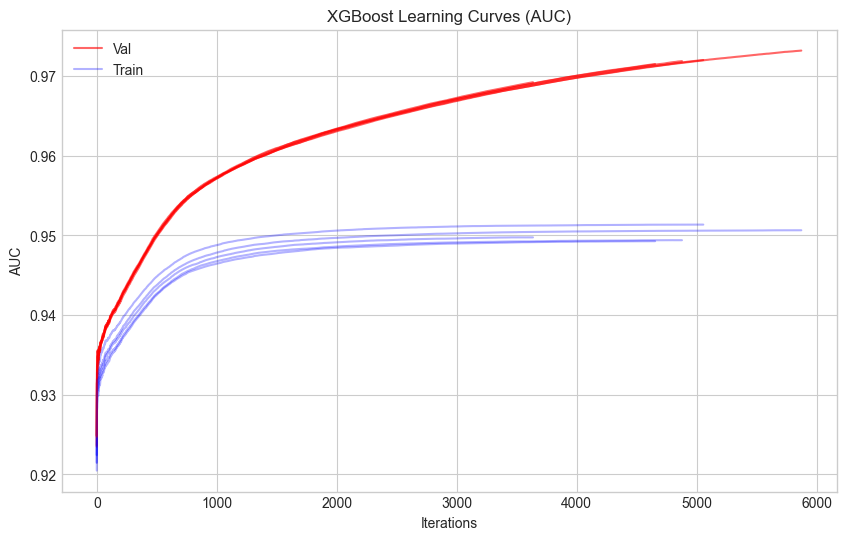

In [11]:
mviz = ModelVisualizer(model_name='XGBoost')

mviz.plot_learning_curves(eval_results, metric='auc')

### Feature Importance
This bar chart ranks which columns had the biggest impact on the model's predictions.
* **Validation Check:** Ensure the top features align with high-signal race dynamics. Features like `TyreLife`, `RaceProgress`, and `Cumulative_Degradation` are expected to be primary indicators for a pit stop.
* **Sanity Check:** Ensure the `id` column does not appear in the top rankings, as this would indicate data leakage.
* **Engineering Check:** Look for engineered features like `LapsRemaining` or `DegradationRate`. Their presence near the top confirms that capturing the trend of tire wear adds more predictive power than static values.

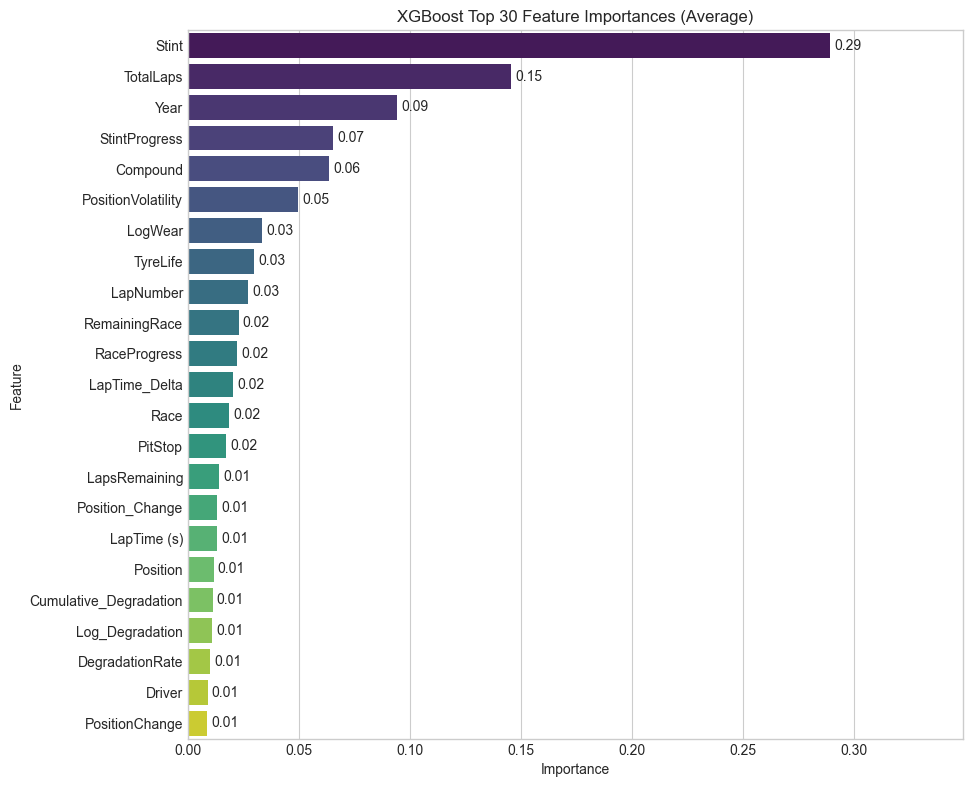

In [12]:
mviz.plot_feature_importance(models, show_values=True)

### Distribution Mismatch
Check if the model is over-predicting a specific irrigation level.  `y` is the actual ground truth, `oof_preds` is the argmax predictions.

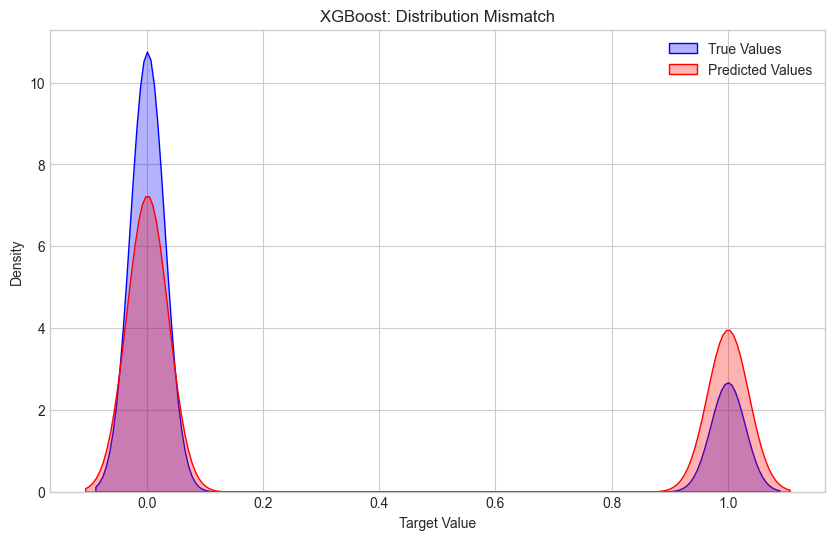

In [13]:
mviz.plot_distribution_mismatch(y_true=y, y_preds=oof_preds)

### Confusion Matrix
The **Confusion Matrix** provides a detailed breakdown of the model's performance for our two binary classes: **0 (No Pit)** and **1 (Pit)**.
* **True Negatives (Top-Left):** Instances where the model correctly predicted the driver would stay out.
* **False Positives (Top-Right):** Instances where the model predicted a pit stop, but the driver stayed out (Type I Error).
* **False Negatives (Bottom-Left):** The model predicted the driver would stay out, but they actually pitted (Type II Error). This is often the most critical error to minimize for strategy prediction.
* **True Positives (Bottom-Right):** Instances where the model correctly predicted a pit stop.

Normalized confusion matrix


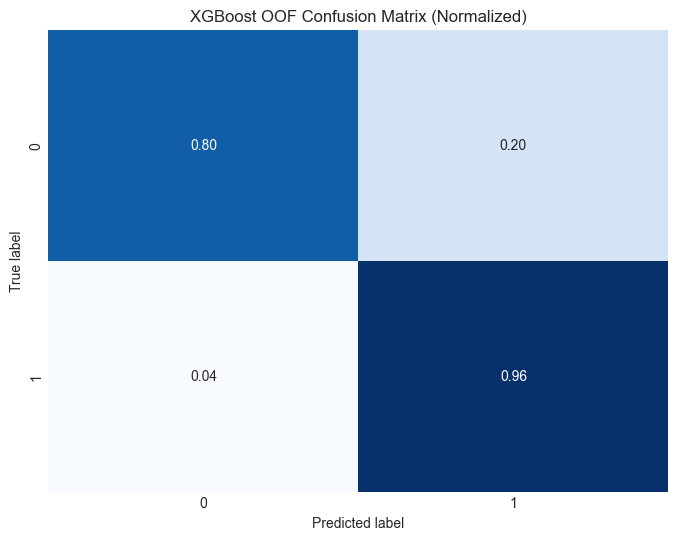

In [14]:
y_pred_class = oof_preds

# Plot the confusion matrix for the 2 binary classes [0, 1]
mviz.plot_confusion_matrix(
    y_true=y, 
    y_pred=y_pred_class, 
    classes=[0, 1], 
    normalize=True, 
    title='XGBoost OOF Confusion Matrix (Normalized)'
)

### ROC Curve & AUC
The **Receiver Operating Characteristic (ROC)** curve illustrates the diagnostic ability of our binary classifier system as its discrimination threshold is varied.
* **The Plot:** It plots the **True Positive Rate (Sensitivity)** against the **False Positive Rate (1 - Specificity)**.
* **The Goal:** We want the blue line to hug the top-left corner as closely as possible, maximizing the area under it.
* **AUC Score:** The **Area Under the Curve (AUC)** summarizes the curve into a single number between 0.5 (random guessing) and 1.0 (perfect classification). This is the primary evaluation metric for this competition.

<Figure size 800x600 with 0 Axes>

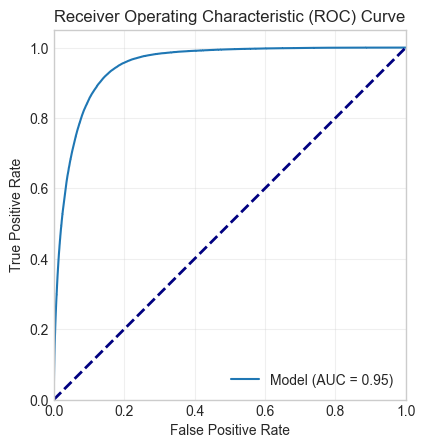

In [15]:
mviz.plot_roc_curve(y_true=y, y_score=oof_probs)

## Prepare Submission

We generate the final submission file according to the competition's schema. The primary evaluation metric is **ROC AUC**, so the submission requires the **probability** of the positive class (`PitNextLap`).

Unlike a hard classification, where we would use a threshold (like 0.5) to decide between 0 and 1, we provide the continuous probability score to allow for nuanced evaluation of the model's confidence across the entire test set.

In [16]:
submission_df = helper.read_dataset('submission')

# Identify the prediction column from the sample submission
pred_col = [c for c in submission_df.columns if c != 'id'][0]
submission_df[pred_col] = pd.Series(test_probs)

print('SAMPLE SUBMISSION')
display(submission_df.head(20))

SAMPLE SUBMISSION


,id,PitNextLap
0,439140,0.029
1,439141,0.052
2,439142,0.023
3,439143,0.669
4,439144,0.987
5,439145,0.831
6,439146,0.002
7,439147,0.017
8,439148,0.076
9,439149,0.006


In [17]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Probabilities

Out-of-fold (OOF) probabilities and averaged test-set probabilities are saved for downstream ensembling (blending or stacking).
  
For this binary classification task, we save the probability scores for the `PitNextLap` event. Saving these raw probabilities is essential for:

- **Weighted Blending**: Combining multiple models by averaging their confidence scores.
- **Stacking**: Using these probabilities as "meta-features" for a secondary model.
- **Calibration Analysis**: Evaluating how well the model's predicted probability aligns with the actual frequency of pit stops.


In [18]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True) 

# Save OOF predictions and raw Test predictions.
# We will load these files in a separate "Blending Notebook".
oof_df = pd.DataFrame({
    'id': training_df['id'].values,
    'prob_xgb': oof_probs,
    'target': y.values
})
oof_df.to_csv(f'{output_dir}/xgb_oof_probs.csv', index=False)

test_pred_df = pd.DataFrame({
    'id': test_df['id'].values,
    'prob_xgb': test_probs
})
test_pred_df.to_csv(f'{output_dir}/xgb_test_probs.csv', index=False)

print(f'Saved for Blending: {output_dir}/xgb_oof_probs.csv, {output_dir}/xgb_test_probs.csv')

Saved for Blending: predictions/xgb_oof_probs.csv, predictions/xgb_test_probs.csv
